# Exploratory Data Analysis (EDA) Report

## Week 2 — Day 3: EDA Workflow

This notebook performs a complete Exploratory Data Analysis workflow, including:

- Dataset overview
- Data types and structure
- Missing-value analysis
- Duplicate-value analysis
- Descriptive statistics
- Numeric distributions
- Correlation analysis
- Outlier identification
- Business insights

In [31]:
df = pd.read_csv("sales_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'sales_data.csv'

In [ ]:
import os

os.getcwd()

'c:\\Users\\Vandana\\Desktop\\sql-fundamentals'

In [ ]:
df = pd.read_csv("python-pandas/sales_data.csv")

In [ ]:
df.head()

,order_id,customer,region,category,sales,quantity
0,1001,Anita,South,Electronics,25000,2
1,1002,Rahul,North,Furniture,18000,1
2,1003,Priya,South,Electronics,32000,3
3,1004,Kiran,West,Clothing,12000,4
4,1005,Suresh,North,Furniture,22000,2


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (10, 6)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   order_id  10 non-null     int64
 1   customer  10 non-null     str  
 2   region    10 non-null     str  
 3   category  10 non-null     str  
 4   sales     10 non-null     int64
 5   quantity  10 non-null     int64
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [ ]:
df.isnull().sum()

order_id    0
customer    0
region      0
category    0
sales       0
quantity    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
Cell In[2], line 1
----> 1 df = pd.read_csv("sales_data.csv")

File ~\Desktop\sql-fundamentals\.venv\Lib\site-packages\pandas\io\parsers\readers.py:873, in read_csv(filepath_or_buffer, sep, delimiter, header, names, index_col, usecols, dtype, engine, converters, true_values, false_values, skipinitialspace, skiprows, skipfooter, nrows, na_values, keep_default_na, na_filter, skip_blank_lines, parse_dates, date_format, dayfirst, cache_dates, iterator, chunksize, compression, thousands, decimal, lineterminator, quotechar, quoting, doublequote, escapechar, comment, encoding, encoding_errors, dialect, on_bad_lines, low_memory, memory_map, float_precision, storage_options, dtype_backend)
    861 kwds_defaults = _refine_defaults_read(
    862     dialect,
    863     delimiter,
   (...)    869     dtype_backend=dtype_backend,
    870 )
    871 kwds.update(kwds_defaults)
--> 873 return _read(filepath_or_buffer, kwds)

File ~\Desktop\sql-fundamentals\.venv\Lib\site-packages\pandas\io\parsers\readers.py:300, in _read(filepath_or_buffer, kwds)
    297 _validate_names(kwds.get("names", None))
    299 # Create the parser.
--> 300 parser = TextFileReader(filepath_or_buffer, **kwds)
    302 if chunksize or iterator:
    303     return parser

File ~\Desktop\sql-fundamentals\.venv\Lib\site-packages\pandas\io\parsers\readers.py:1645, in TextFileReader.__init__(self, f, engine, **kwds)
   1642     self.options["has_index_names"] = kwds["has_index_names"]
   1644 self.handles: IOHandles | None = None
-> 1645 self._engine = self._make_engine(f, self.engine)
...
    937     else:
    938         # Binary mode
    939         handle = open(handle, ioargs.mode)

FileNotFoundError: [Errno 2] No such file or directory: 'sales_data.csv'
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
'c:\\Users\\Vandana\\Desktop\\sql-fundamentals'
order_id	customer	region	category	sales	quantity
0	1001	Anita	South	Electronics	25000	2
1	1002	Rahul	North	Furniture	18000	1
2	1003	Priya	South	Electronics	32000	3
3	1004	Kiran	West	Clothing	12000	4
4	1005	Suresh	North	Furniture	22000	2
Dataset shape: (10, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   order_id  10 non-null     int64
 1   customer  10 non-null     str  
 2   region    10 non-null     str  
 3   category  10 non-null     str  
 4   sales     10 non-null     int64
 5   quantity  10 non-null     int64
dtypes: int64(3), str(3)
memory usage: 612.0 bytes
order_id    0
customer    0
region      0
category    0
sales       0
quantity    0
dtype: int64
np.int64(0)
df.describe()

,order_id,sales,quantity
count,10.00000,10.000000,10.000000
mean,1005.50000,21750.000000,2.100000
std,3.02765,8203.149802,0.994429
min,1001.00000,11000.000000,1.000000
25%,1003.25000,15750.000000,1.250000
50%,1005.50000,20750.000000,2.000000
75%,1007.75000,27250.000000,2.750000
max,1010.00000,35000.000000,4.000000


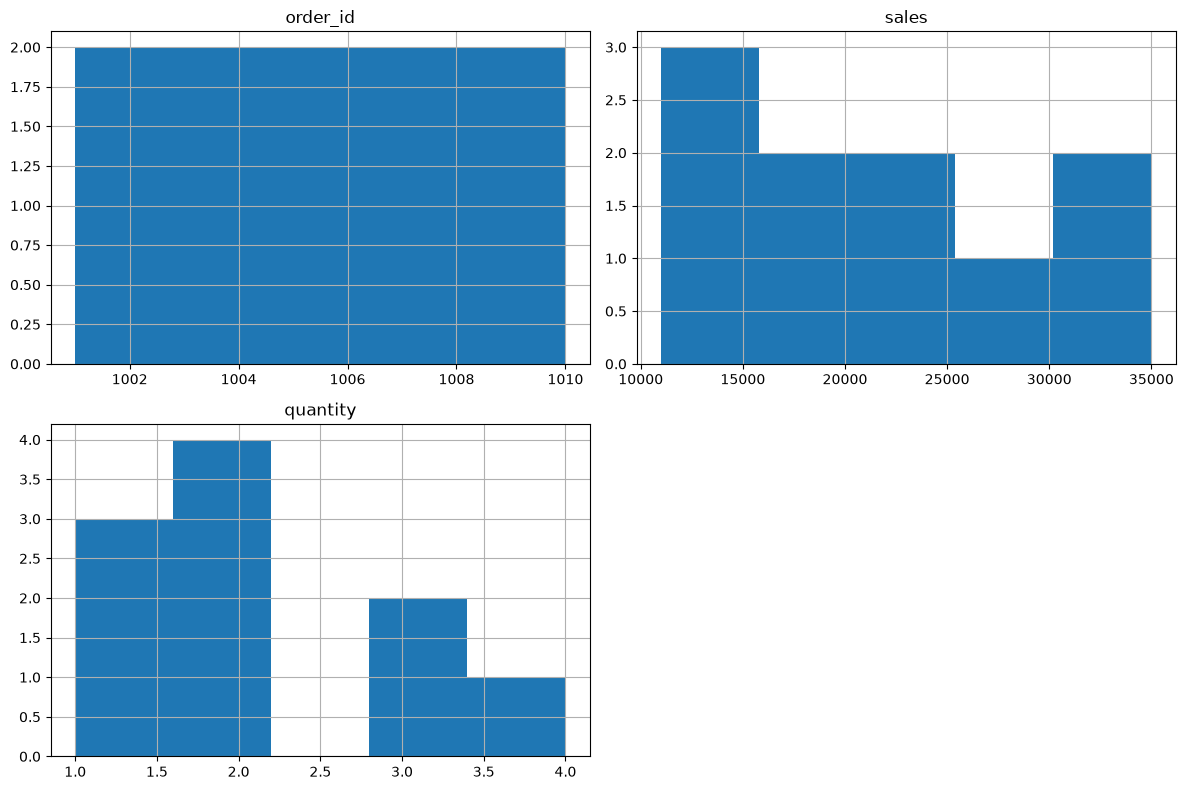

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(12, 8), bins=5)

plt.tight_layout()
plt.show()

In [ ]:


correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,order_id,sales,quantity
order_id,1.000000,0.081646,-0.166070
sales,0.081646,1.000000,-0.275822
quantity,-0.166070,-0.275822,1.000000


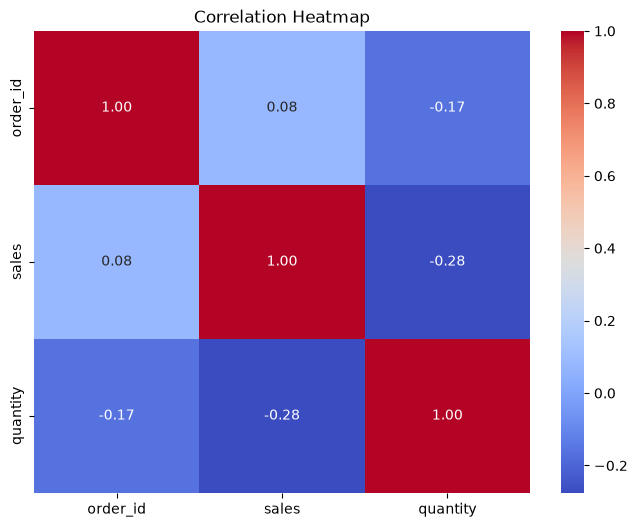

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append([
        col,
        outlier_count,
        lower_bound,
        upper_bound
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Outlier Count",
        "Lower Bound",
        "Upper Bound"
    ]
)

outlier_df

,Column,Outlier Count,Lower Bound,Upper Bound
0,order_id,0,996.5,1014.5
1,sales,0,-1500.0,44500.0
2,quantity,0,-1.0,5.0


In [ ]:
df.loc[df["sales"].idxmax()]

order_id           1010
customer           Neha
region             West
category    Electronics
sales             35000
quantity              2
Name: 9, dtype: object

In [ ]:
df.loc[df["sales"].idxmin()]

order_id        1008
customer       Divya
region         North
category    Clothing
sales          11000
quantity           3
Name: 7, dtype: object

In [32]:
sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)

sales_by_region

region
South    91500
West     75000
North    51000
Name: sales, dtype: int64

In [34]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)

sales_by_category

category
Electronics    120000
Furniture       59500
Clothing        38000
Name: sales, dtype: int64

## Business Insights

Based on the exploratory analysis:

1. The dataset contains 10 sales records across different regions and product categories.

2. There are no missing values in the dataset, so the available records are complete.

3. There are no duplicate rows in the dataset.

4. Sales values range from 11,000 to 35,000, with an average sales value of 21,750.

5. The quantity sold ranges from 1 to 4 units, with an average quantity of 2.1 units.

6. Regional and category-level sales totals were calculated to identify differences in sales performance.

7. Correlation analysis was performed on the numeric variables to understand relationships between sales, quantity, and order ID.

8. The IQR method was used to identify potential outliers in the numeric columns.+

## Conclusion

The EDA workflow provided an overall understanding of the sales dataset.

The analysis covered dataset structure, data types, missing values, duplicate records, descriptive statistics, numeric distributions, correlation analysis, outlier detection, and business-level sales analysis.

The dataset is clean with no missing values or duplicate rows. Further analysis can focus on regional and category-level sales performance to identify opportunities for deeper business analysis.+

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns